In [1]:
import torch, torchvision
import torch.nn as nn
import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt

import re
from tqdm.notebook import tqdm

from shared import *

cudnn.benchmark = True
plt.ion();

In [2]:
BASE = "cifar10-data"
BASE_PLOTS = os.path.join(BASE, "plots")
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR = 0.001
MOMENTUM = 0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 5

LAYER_SUFFIXES = ["1.0", "2.7", "4.2"]

os.makedirs(BASE_PLOTS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


# 3. Feature Hierarchies and Representations

In [3]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE, num_workers=4)

In [4]:
def load_model(pretrained=True):
    weights = torchvision.models.ResNet152_Weights.IMAGENET1K_V1 if pretrained else None
    return torchvision.models.resnet152(weights=weights)

def add_clf_head(resnet):
    n_features = resnet.fc.in_features
    resnet.fc = nn.Linear(n_features, 10, bias=True)
    return resnet

In [5]:
class FeatureTracker:
    def __init__(self, model):
        self.layer_name_pattern = r'^layer[0-9]\.[0-9]$'  # e.g. layer1.1, layer2.0, etc
        self.features = {name: [] for name, _ in model.named_modules() if re.search(self.layer_name_pattern, name) and name.replace('layer', '') in LAYER_SUFFIXES}
        self.labels = []
        self.handles = []
        self._register_hooks(model)
        
    def _register_hooks(self, model):
        for name, module in model.named_modules():
            if re.search(self.layer_name_pattern, name) and name.replace('layer', '') in LAYER_SUFFIXES:
                print(f"Registering hook for {name}")
                def hook_fn(module, args, output, name=name):
                    if name in self.features:
                        self.features[name].append(output.detach())
                handle = module.register_forward_hook(hook_fn)
                self.handles.append(handle)
    
    def unregister(self):
        for handle in self.handles:
            handle.remove()

In [6]:
def track_val_features(model, num_batches=6):
    was_training = model.training
    tracker_features = FeatureTracker(model_vis)
    model.eval()
    
    with torch.inference_mode(), tqdm(total=num_batches) as pbar:
        for i, (inputs, labels) in enumerate(dataloaders['val'], start=1):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            _ = model(inputs)
            tracker_features.labels.append(labels.detach())

            pbar.update(1)
                
            if i == num_batches:
                model.train(mode=was_training)
                break
        
    model.train(mode=was_training)
    tracker_features.unregister()
    
    return tracker_features.features, tracker_features.labels

In [16]:
model_vis = load_model().to(DEVICE)

In [17]:
features, labels = track_val_features(model_vis, num_batches=3)

Registering hook for layer1.0
Registering hook for layer2.7
Registering hook for layer4.2


  0%|          | 0/3 [00:00<?, ?it/s]

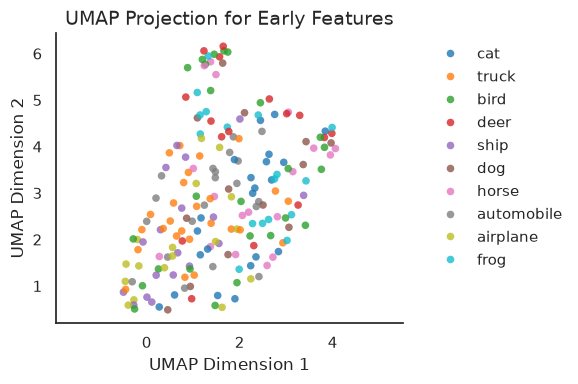

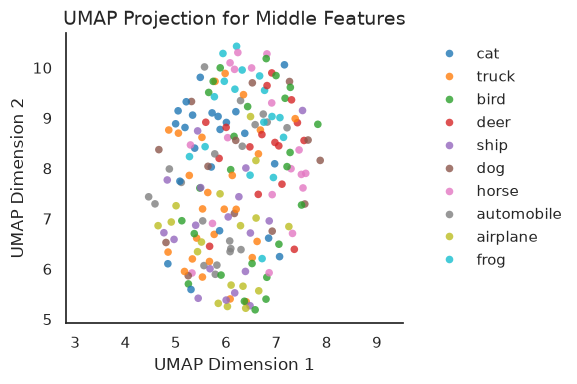

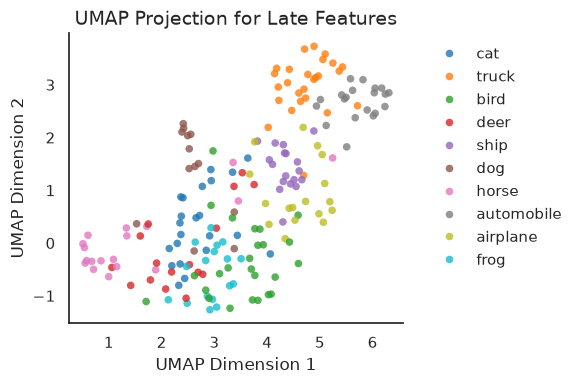

In [18]:
for layer_suffix, placement in zip(LAYER_SUFFIXES, ["early", "middle", "late"]):
    subset = features[f"layer{layer_suffix}"]
    visualize_umap_features(torch.concat(subset).cpu(), torch.concat(labels).cpu(), dataloaders["val"].dataset.classes, f"UMAP Projection for {placement.title()} Features")
    plt.savefig(os.path.join(BASE_PLOTS, f"cifar10_umap_{layer_suffix}.pdf"), dpi=300)
    plt.show()

In [19]:
del model_vis
del features
del labels

free_mem()